# NBA Players Data Analysis and Visualization

## Objective
The objective of this project is to analyze NBA player demographics, team composition, physical attributes, and salary patterns using data visualization techniques.

## Libraries Used

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

## Load Dataset

In [2]:
df = pd.read_csv('nba.csv')
df

,name,team,number,position,age,height[inch],weight,college,salary
0,Player_1,Boston Celtics,0,PG,25,6.2,180,Texas,7730337.0
1,Player_2,Boston Celtics,99,SF,25,6.6,235,Marquette,6796117.0
2,Player_3,Boston Celtics,0,SG,27,6.5,205,Boston University,NaN
3,Player_4,Boston Celtics,28,SG,22,6.5,185,Georgia State,1148640.0
4,Player_5,Boston Celtics,8,PF,29,6.1,231,NaN,5000000.0
...,...,...,...,...,...,...,...,...,...
452,Player_453,Chicago Bulls,51,C,33,7.0,258,NaN,9000000.0
453,Player_454,Boston Celtics,14,PG,24,6.2,180,NaN,2800000.0
454,Player_455,Boston Celtics,27,SG,26,6.5,205,Miami,4500000.0
455,Player_456,Boston Celtics,49,PF,32,6.1,248,NaN,8200000.0


## Data Exploration

In [7]:
# Dataset Information
print(df.info())
print(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 457 entries, 0 to 456
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   name          457 non-null    object 
 1   team          457 non-null    object 
 2   number        457 non-null    int64  
 3   position      457 non-null    object 
 4   age           457 non-null    int64  
 5   height[inch]  457 non-null    float64
 6   weight        457 non-null    int64  
 7   college       457 non-null    object 
 8   salary        457 non-null    float64
dtypes: float64(2), int64(3), object(4)
memory usage: 32.3+ KB
None
           number         age  height[inch]      weight        salary
count  457.000000  457.000000    457.000000  457.000000  4.570000e+02
mean    24.214442   27.459519      6.533939  216.912473  5.624729e+06
std     17.952727    4.192595      0.374680   32.092332  4.227000e+06
min      0.000000   20.000000      6.000000  170.000000  9.000000e+05
25%  

In [6]:
# check missing values
df.isnull().sum()

name            0
team            0
number          0
position        0
age             0
height[inch]    0
weight          0
college         0
salary          0
dtype: int64

In [3]:
# Fill missing college values
df['college'] = df['college'].fillna('Unknown')

# Fill missing salary with median salary
df['salary'] = df['salary'].fillna(df['salary'].median())

In [4]:
df.isnull().sum()

name            0
team            0
number          0
position        0
age             0
height[inch]    0
weight          0
college         0
salary          0
dtype: int64

## Data Cleaning

The dataset contained missing values in the college and salary columns.

- 327 missing values in the college column were replaced with "Unknown".
- 1 missing value in the salary column was replaced with the median salary.

After handling missing values, the dataset contained no null values and was ready for analysis and visualization.

# Data Analysis and Visualization

## Matplotlib / Seaborn

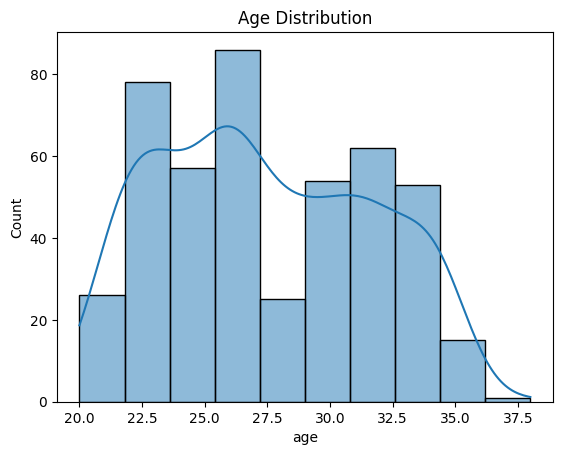

In [55]:
# 1. Age Distribution
'''
kde=True adds a smooth density curve on a histogram.
KDE Curve Meaning
Higher curve → more data concentration
Lower curve → fewer data points
'''
sns.histplot(df['age'],bins=10,kde=True)
plt.title('Age Distribution')
plt.show()

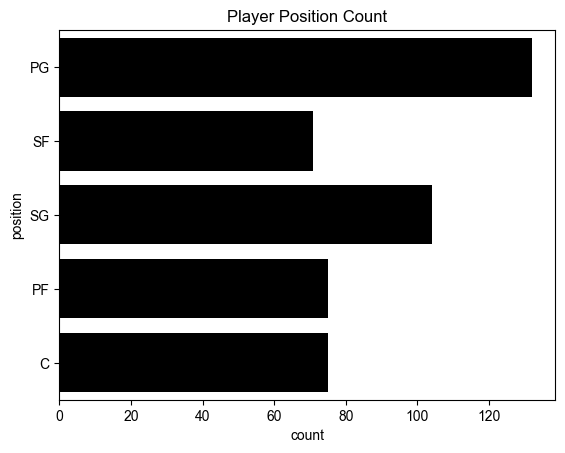

In [56]:
# Player Position Count
sns.countplot(df['position'],color= 'black')
sns.set_style('darkgrid')
plt.title('Player Position Count')
plt.show()

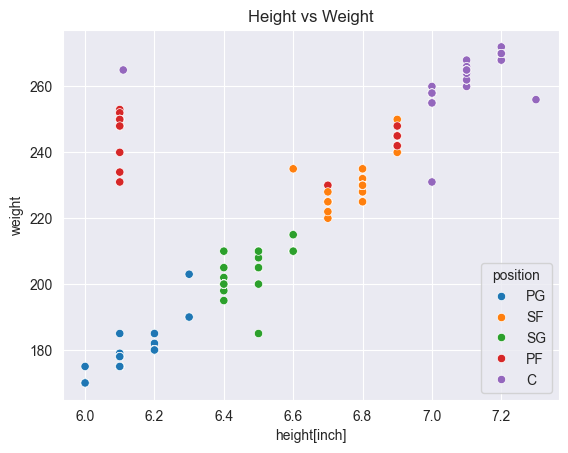

In [57]:
# 7.Height vs Weight
sns.scatterplot(x='height[inch]',y='weight',hue= 'position',data=df)
plt.title('Height vs Weight')
plt.show()

<Axes: xlabel='salary'>

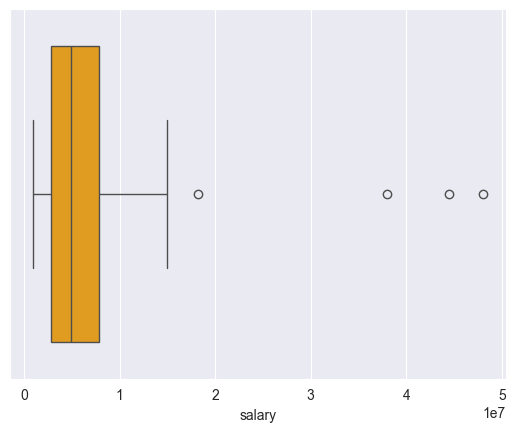

In [58]:
# 8.Salary Distribution
sns.boxplot(x='salary',data=df, color='orange')

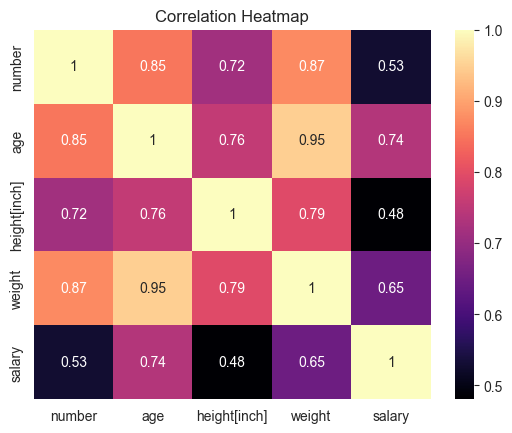

In [59]:
# 9.Correlation Heatma[Correlation: relationship between variables]
'''
Value	Meaning
1   	Strong positive relation
0	    No relation
-1	    Strong negative relation
'''
'''
Colormap	Style
coolwarm	Blue ↔ Red
viridis	    Green-Yellow
plasma	    Purple-Yellow
magma	    Dark theme

'''
sns.heatmap(df.corr(numeric_only=True),
            annot=True,
            cmap='magma')# annot = True appear numbers

plt.title("Correlation Heatmap")

plt.show()

In [63]:
print(df.columns.tolist())

['name', 'team', 'number', 'position', 'age', 'height[inch]', 'weight', 'college', 'salary']


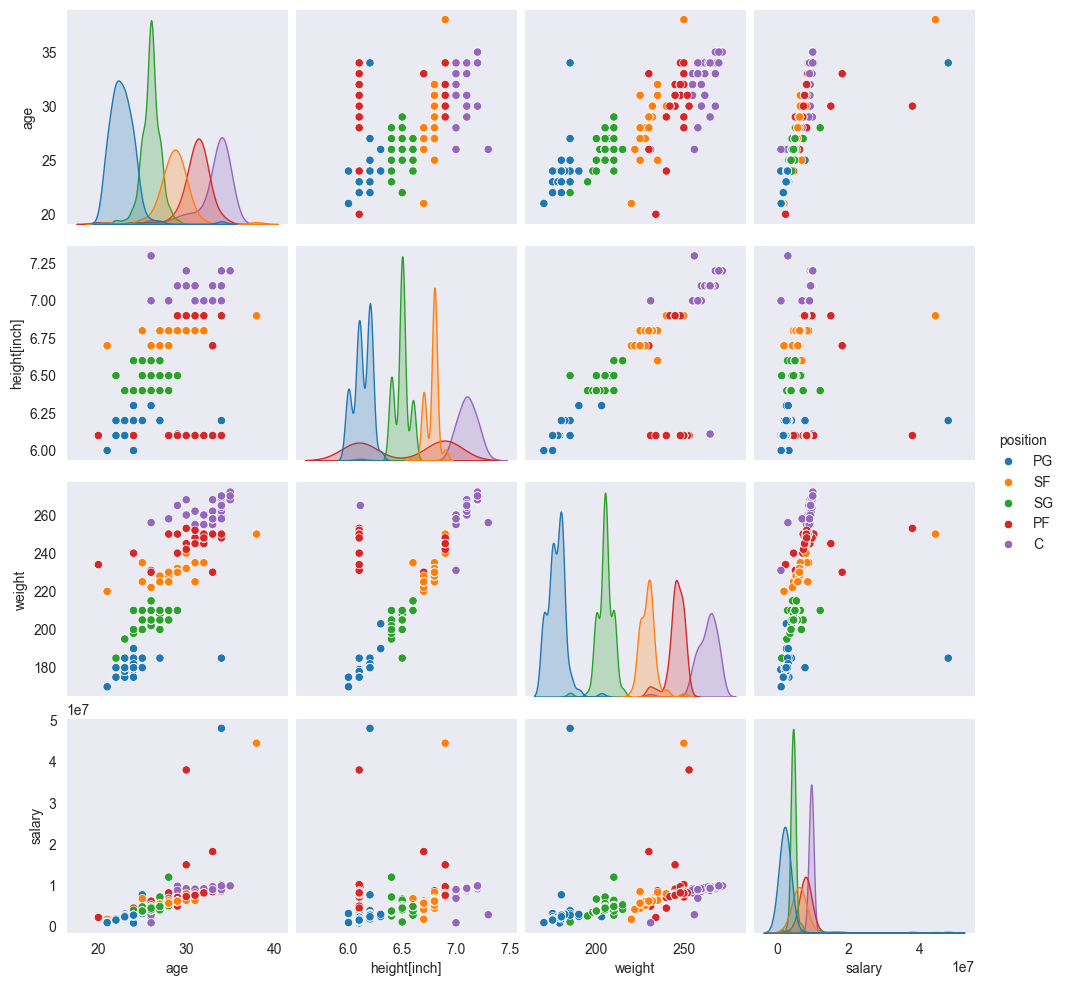

In [64]:
# Pair Plot
sns.set_style('dark')

sns.pairplot(
    df[['age','height[inch]','weight','salary','position']],
    hue='position'
)

plt.show()

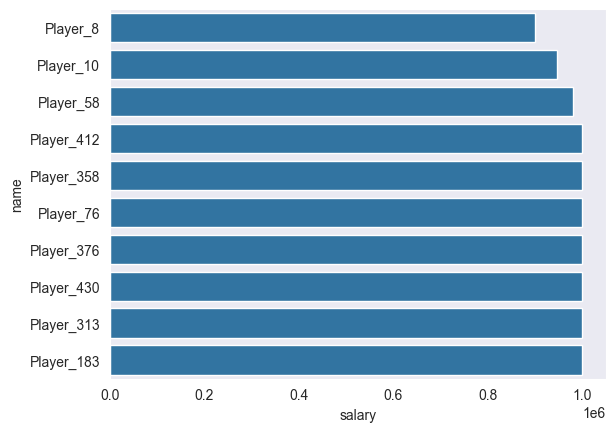

In [65]:
# Top 10 highest paid players
top_salary = df.sort_values(by='salary',ascending=True).head(10)
sns.barplot(x='salary',y='name',data=top_salary)
plt.show()

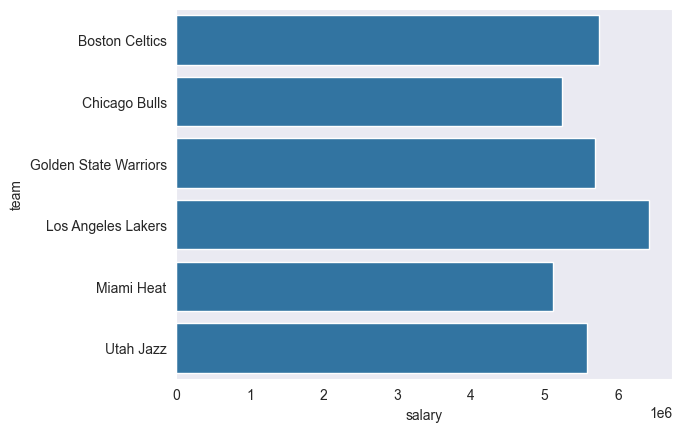

In [66]:
# Average Salary by Team
Team_sal = df.groupby('team')['salary'].mean().reset_index()
sns.barplot(x='salary',y='team',data=Team_sal)
plt.show()

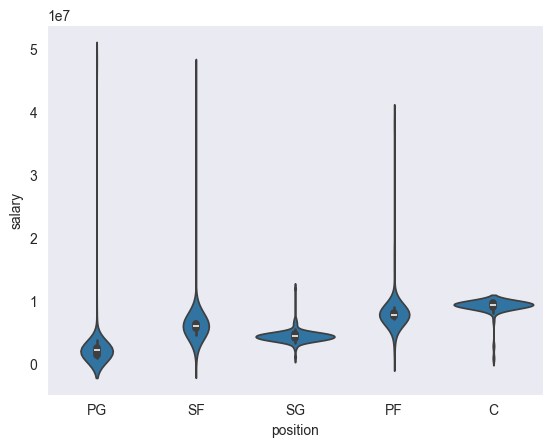

In [67]:
# Salary Distribution by Position
'''
Width of Shape
Wider area → more players in that salary range
Narrow area → fewer players
'''
sns.violinplot(x='position',y='salary',data=df)
plt.show()

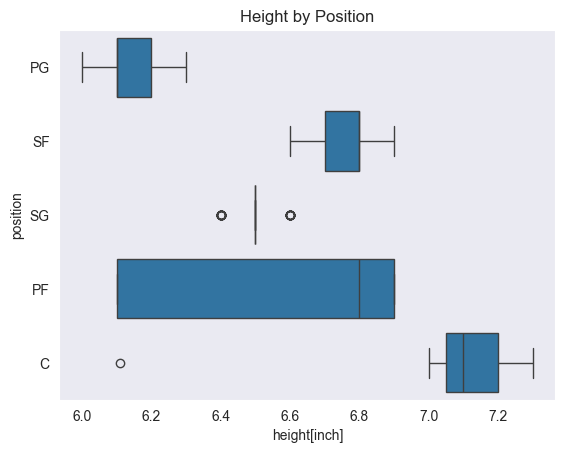

In [68]:
# Height by Position
sns.boxplot(x='height[inch]',y='position',data=df)

plt.title("Height by Position")

plt.show()

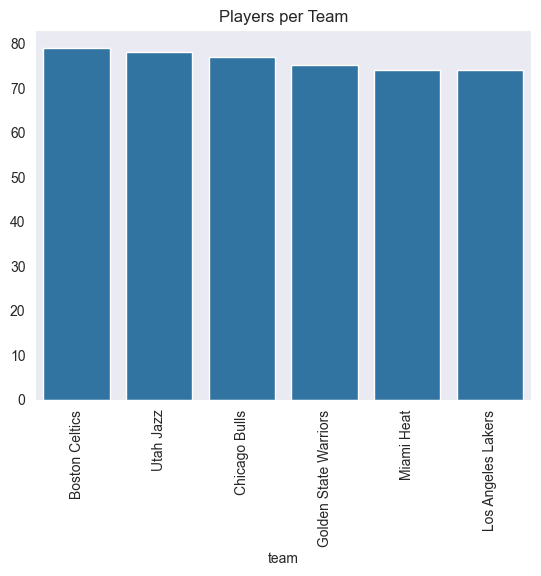

In [69]:
# Team-wise Player Count
team_count = df['team'].value_counts()
sns.barplot(x=team_count.index, y=team_count.values)
plt.xticks(rotation=90)
plt.title("Players per Team")
plt.show()

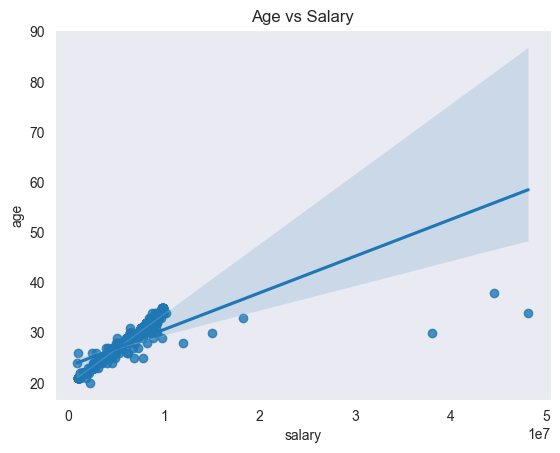

In [70]:
# Salary vs Age Regression Plot
sns.regplot(x='salary',y='age',data=df)
plt.title("Age vs Salary")
plt.show()

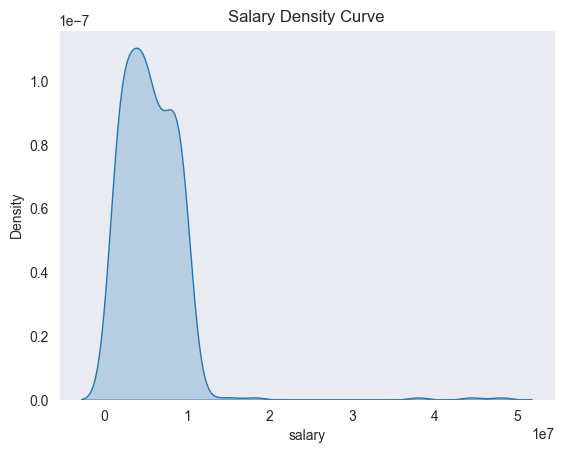

In [71]:
# Salary Density Curve
sns.kdeplot(df['salary'],fill=True)

plt.title("Salary Density Curve")

plt.show()

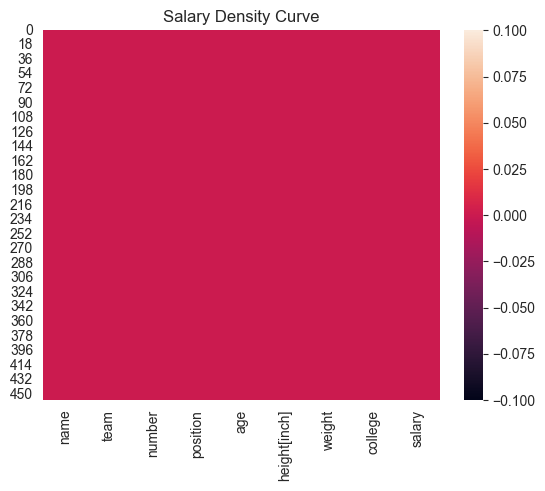

In [72]:
# Missing Values Heatmap
sns.heatmap(df.isnull(),cbar=True)
plt.title('Salary Density Curve')
plt.show()

## Plotly Visualizations

In [ ]:
# syntax of plotly
'''
import plotly.express as px
fig = px.chart_type(dataframe,x='column1',y = 'column2',color='column3')
fig.show()
'''

In [ ]:
import os  # Used to interact with the operating system (folders, files, etc.)

# Create a folder named "plots" to store static images (PNG)
# exist_ok=True means: don't throw error if folder already exists
os.makedirs("plots", exist_ok=True)

# Create a folder named "interactive_plots" to store Plotly HTML files
# These files open in browser with full interactivity
os.makedirs("interactive_plots", exist_ok=True)

In [7]:
# Number of players by team
team_count = df['team'].value_counts().reset_index()
team_count.columns = ['team','count']
fig = px.bar(team_count,x='team',y='count', title='Number of Players by Team')
fig.show()
fig.write_image("plots/team_chart.png")   # static image
fig.write_html("interactive_plots/team_chart.html")  # interactive

In [8]:
# Position Distribution

position_count = df['position'].value_counts().reset_index()
position_count.columns = ['position','count']
fig = px.pie(position_count, values='count', names='position', title='Position Distribution')
fig.show()
fig.write_image("plots/team_chart.png")   # static image
fig.write_html("interactive_plots/team_chart.html")  # interactive

In [9]:
# Age Distribution
fig = px.histogram(df,x='age',nbins=10,title='Age Distribution')
fig.update_traces(marker_line_width=1, marker_line_color='black')
fig.show()

fig.write_image("plots/team_chart.png")   # static image
fig.write_html("interactive_plots/team_chart.html")  # interactive

In [ ]:
# Height vs Weight
fig = px.scatter(df,x='height[inch]',y='weight',color='position',hover_name='name',title='Height vs Weight')
fig.show()

fig.write_image("plots/height_weight.png")   # static image
fig.write_html("interactive_plots/height_weight.html")  # interactive

In [11]:
# Salary by position
fig = px.box(df,x='position',y='salary',color='position',title='Salary by Position')
fig.show()

fig.write_image("plots/team_chart.png")   # static image
fig.write_html("interactive_plots/team_chart.html")  # interactive

In [13]:
# Age distribution by position
fig = px.violin(df,x='position',y='age',color='position',title='Age Distribution by Position')
fig.show()

fig.write_image("plots/team_chart.png")   # static image
fig.write_html("interactive_plots/team_chart.html")  # interactive

In [14]:
# college --> team

fig = px.treemap(df,path=['college','team'],values='salary',title='College to Team Distribution')
fig.show()

fig.write_image("plots/team_chart.png")   # static image
fig.write_html("interactive_plots/team_chart.html")  # interactive

In [15]:
# team --> position ---> player
fig = px.sunburst(df,path=['team','position','name'],values='salary',title='Team to Position to Player Distribution')
fig.show()

fig.write_image("plots/team_chart.png")   # static image
fig.write_html("interactive_plots/team_chart.html")  # interactive

In [16]:
# height vs weight by position density
fig = px.density_contour(df,x='height[inch]',y='weight',color='position',title='Height vs Weight Density')
fig.show()

fig.write_image("plots/team_chart.png")   # static image
fig.write_html("interactive_plots/team_chart.html")  # interactive

In [18]:
# age vs height vs weight
fig = px.scatter_3d(df,x='age',y='height[inch]',z='weight',color='position',title='Age vs Height vs Weight')
fig.show()

fig.write_image("plots/age_height_weight.png")   # static image
fig.write_html("interactive_plots/age_height_weight.html")  # interactive

## Key Findings

- The most common player position in the dataset is Point Guard (PG).
- The average age of NBA players is 27.46 years.
- Boston Celtics has the highest number of players in the dataset.
- Player_9 is the tallest player in the dataset.
- Player_309 is the heaviest player in the dataset.
- Player_16 is the highest-paid player in the dataset.
- Height and weight show a positive relationship, indicating that taller players generally weigh more.
- Centers (C) have the highest average salary ($9.20 million), followed by Power Forwards (PF).
- Point Guards (PG) have the lowest average salary ($2.43 million).
- Salary varies significantly across different player positions.

## Conclusion

This project analyzed NBA player data using Pandas, Matplotlib, Seaborn, and Plotly. The analysis explored player demographics, team composition, physical attributes, and salary patterns. Interactive visualizations helped uncover relationships between variables and provided valuable insights into player characteristics and salary distribution across different positions.